In [1]:
# Imports and Load Data
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
import pywt
import cv2

with open("ssl_features.pkl", "rb") as f:
    data = pickle.load(f)

features = np.array(data["features"])
labels = np.array(data["labels"])

print(f"Features shape: {features.shape}, Labels shape: {labels.shape}")


Features shape: (1000, 512), Labels shape: (1000,)


C:\Users\Dabie\AppData\Local\Temp\ipykernel_14180\2667193326.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="coolwarm")


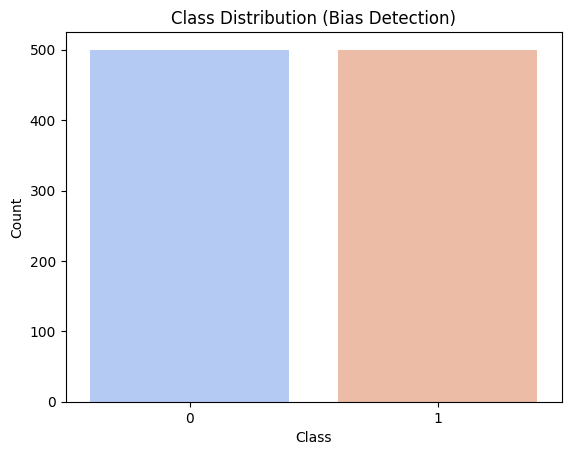

In [2]:
# Bias Detection (Class Imbalance)
unique, counts = np.unique(labels, return_counts=True)
sns.barplot(x=unique, y=counts, palette="coolwarm")
plt.title("Class Distribution (Bias Detection)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


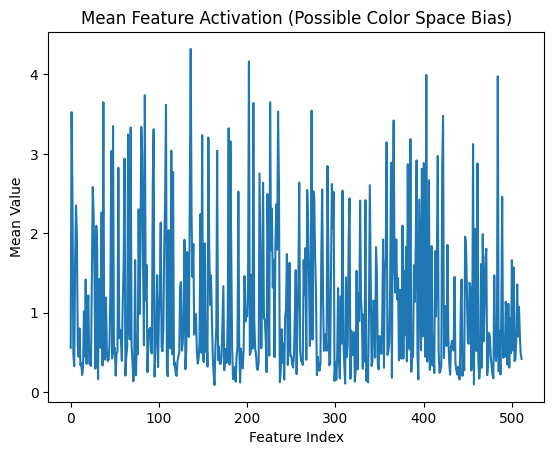

In [ ]:
# Color Space Analysis (if features are RGB stats)
mean_values = features.mean(axis=0)
plt.plot(mean_values)
plt.title("Mean Feature Activation (Possible Color Space Bias)")
plt.xlabel("Feature Index")
plt.ylabel("Mean Value")
plt.show()


In [ ]:
# Discrepancy Test (KL Divergence between classes)
class0 = features[labels == 0].mean(axis=0)
class1 = features[labels == 1].mean(axis=0)
p = np.abs(class0) / np.sum(np.abs(class0))
q = np.abs(class1) / np.sum(np.abs(class1))
kl_div = entropy(p + 1e-10, q + 1e-10)
print(f"KL Divergence (Feature Discrepancy): {kl_div:.4f}")


KL Divergence (Feature Discrepancy): 0.0337


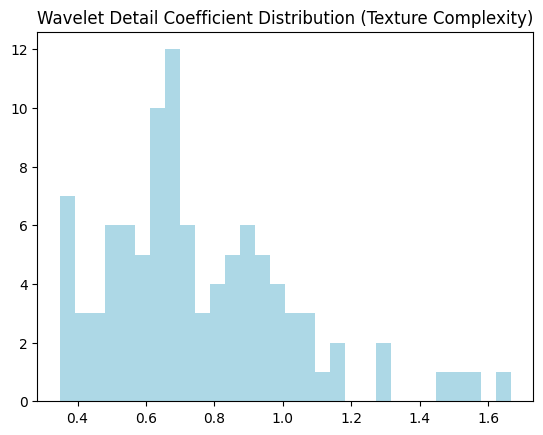

In [ ]:
# DFT & Wavelet Transform Analysis
wavelet_coeffs = []
for i in range(min(100, len(features))):
    coeffs = pywt.dwt(features[i], "db1")
    cA, cD = coeffs
    wavelet_coeffs.append(np.mean(np.abs(cD)))
plt.hist(wavelet_coeffs, bins=30, color="lightblue")
plt.title("Wavelet Detail Coefficient Distribution (Texture Complexity)")
plt.show()


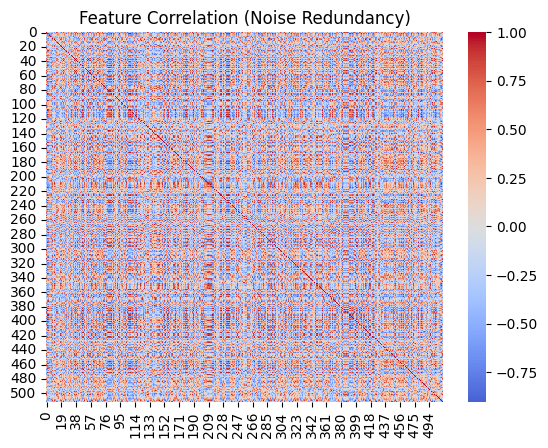

In [ ]:
# Noise Redundancy and Correlation
corr_matrix = np.corrcoef(features.T)
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation (Noise Redundancy)")
plt.show()


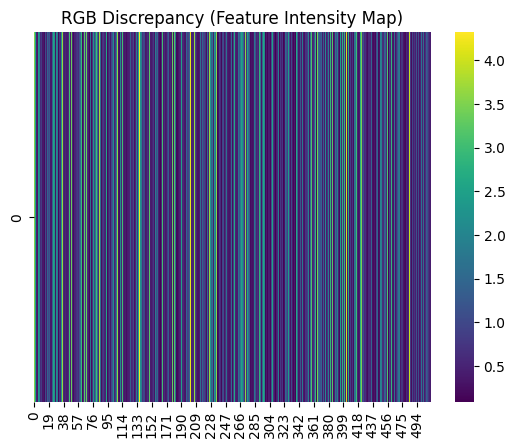

In [7]:
# RGB Discrepancy Heatmap
sns.heatmap(np.expand_dims(mean_values, axis=0), cmap="viridis", cbar=True)
plt.title("RGB Discrepancy (Feature Intensity Map)")
plt.show()


In [8]:
# Wavelet Energy Summary
wavelet_energy = np.mean(np.square(wavelet_coeffs))
print(f"Average Wavelet Energy: {wavelet_energy:.4f}")


Average Wavelet Energy: 0.6402


In [9]:
# Summary
print("Feature analysis complete — bias, texture, and redundancy visualization done.")


Feature analysis complete — bias, texture, and redundancy visualization done.
